# Clase 17: Escalamiento y estandarización de variables (Feature Scaling)
**Modalidad: Autoestudio**

En las sesiones anteriores, aprendimos a identificar problemas en la *forma* de nuestras distribuciones (como el sesgo) y cómo corregirlos mediante transformaciones matemáticas como el Logaritmo y Box-Cox.

Hoy daremos el último paso crítico en la preparación de variables numéricas (*Feature Engineering*) antes de alimentar cualquier modelo predictivo. Aprenderemos a modificar la **escala** (el rango numérico en el eje X) de nuestros datos sin alterar la forma de su distribución original.

### El problema en el mundo real:
Imagina un dataset para predecir el precio de una casa que incluye dos variables:
1. **Número de recámaras:** Rango típico de $1$ a $5$.
2. **Ingreso anual del comprador:** Rango típico de $\$20,000$ a $\$2,000,000$.

Si alimentamos un algoritmo basado en distancias (como K-Means o KNN) o basado en optimización por gradiente (como Regresión Ridge o Redes Neuronales) con estos datos directos, el algoritmo asumirá que una diferencia de $\$10,000$ en los ingresos es masivamente más importante que una diferencia de $2$ recámaras. La variable con la escala numérica más grande **absorberá y sesgará por completo al modelo**, haciendo que ignore las características de escala pequeña.

### Objetivos de hoy:
1. Comprender la diferencia matemática entre **Estandarizar** (StandardScaler) y **Normalizar** (MinMaxScaler).
2. Implementar de forma práctica estas transformaciones usando la librería estándar de la industria: `scikit-learn`.
3. Entender el concepto crítico de **Data Leakage** (Fuga de datos) al escalar.

In [6]:
# Descomentar la siguiente línea si no tienes instalado sklearn
%pip install sklearn
%pip install seaborn
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.2 MB 12.6 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.2 MB 9.8 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 9.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 8.3 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.6 MB 6.5 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/36.6 MB 6.4 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/36.6 MB 6.6 MB/s eta 0:00:05
   ------ --------------------

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Fijamos la semilla para reproducibilidad
np.random.seed(42)

# Simulamos dos variables reales con escalas masivamente distintas
edad = np.random.normal(loc=35, scale=8, size=1000)          # Rango aprox: 15 a 60
ingreso_anual = np.random.normal(loc=65000, scale=15000, size=1000) # Rango aprox: 20,000 a 110,000

# Juntamos las variables en una matriz de características (X)
X = np.column_stack((edad, ingreso_anual))

print("--- Estadísticos Originales ---")
print(f"Edad          -> Mín: {edad.min():.1f}, Máx: {edad.max():.1f}, Media: {edad.mean():.1f}, Desv.Std: {edad.std():.1f}")
print(f"Ingreso Anual -> Mín: {ingreso_anual.min():.1f}, Máx: {ingreso_anual.max():.1f}, Media: {ingreso_anual.mean():.1f}, Desv.Std: {ingreso_anual.std():.1f}")

--- Estadísticos Originales ---
Edad          -> Mín: 9.1, Máx: 65.8, Media: 35.2, Desv.Std: 7.8
Ingreso Anual -> Mín: 20894.2, Máx: 112896.6, Media: 66062.5, Desv.Std: 14954.3


## Las dos herramientas principales de escalamiento

Para solucionar este desbalance de magnitudes, recurrimos a dos técnicas fundamentales:

### 1. Estandarización (StandardScaler / Z-Score)
Transforma los datos para que tengan una **media ($\mu$) igual a 0** y una **desviación estándar ($\sigma$) igual a 1**. 

* **Fórmula matemática:** $z = \frac{x - \mu}{\sigma}$
* **¿Cuándo usarla?:** Es ideal para variables que siguen (o aproximan) una distribución Normal. Es altamente recomendada para algoritmos como Regresión Lineal, Regresión Logística, Máquinas de Soporte Vectorial (SVM) y Análisis de Componentes Principales (PCA). A diferencia de MinMaxScaler, **no tiene un límite máximo ni mínimo fijo** y es más robusta ante la presencia de algunos valores atípicos (*outliers*).



### 2. Normalización Min-Max (MinMaxScaler)
Transforma y "comprime" linealmente todos los valores numéricos para que queden estrictamente acotados dentro de un rango fijo predeterminado, usualmente **entre 0 y 1**.

* **Fórmula matemática:** $x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$
* **¿Cuándo usarla?:** Es indispensable cuando el algoritmo requiere rangos fijos acotados (como en el procesamiento de imágenes donde los píxeles van de 0 a 255, o en Redes Neuronales Artificiales). Es la opción por defecto si no conoces la distribución subyacente de tus datos o para algoritmos basados en distancias como KNN y K-Means. 
* *¡Cuidado!*: Si tus datos tienen un *outlier* masivo, esta técnica comprimirá el resto de tus datos normales en un rango diminuto (por ejemplo, entre 0 y 0.05), perdiendo variabilidad útil.

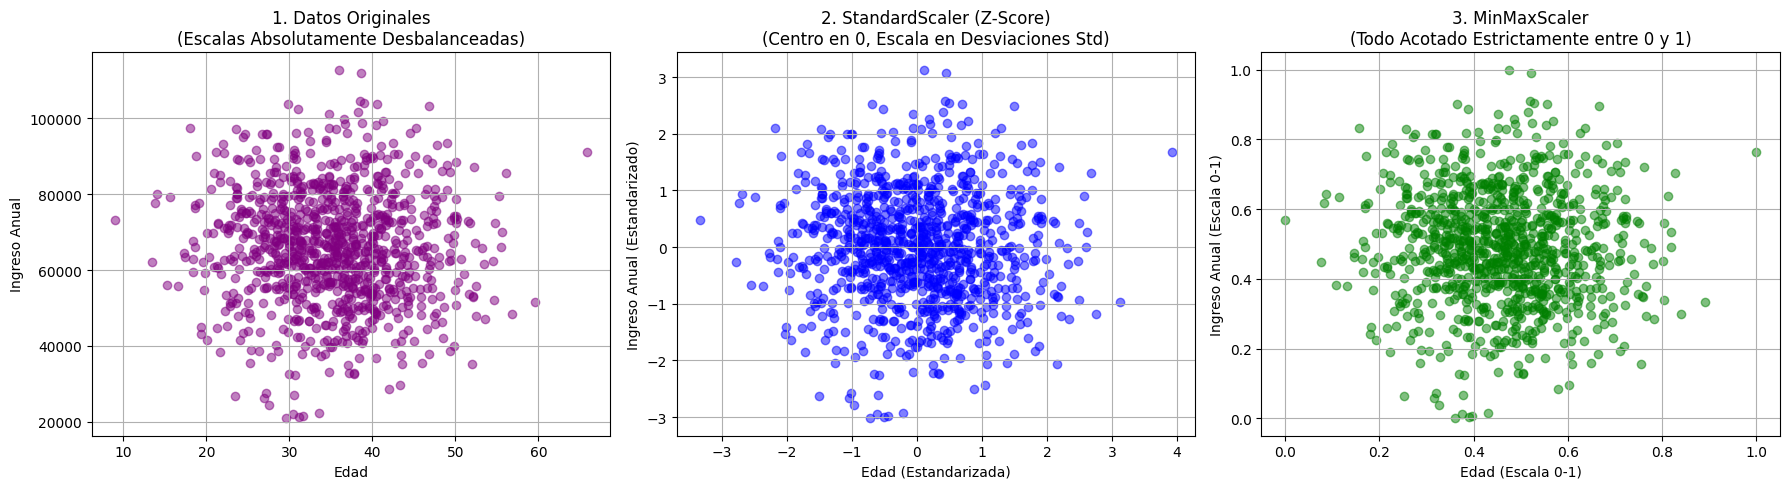

In [8]:
# 1. Aplicamos la Estandarización (StandardScaler)
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

# 2. Aplicamos la Normalización Min-Max (MinMaxScaler)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

# Graficamos el impacto geométrico para el análisis de los alumnos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Escala Original
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, color='purple')
axes[0].set_title("1. Datos Originales\n(Escalas Absolutamente Desbalanceadas)")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Ingreso Anual")
axes[0].grid(True)

# Gráfico 2: StandardScaler
axes[1].scatter(X_std[:, 0], X_std[:, 1], alpha=0.5, color='blue')
axes[1].set_title("2. StandardScaler (Z-Score)\n(Centro en 0, Escala en Desviaciones Std)")
axes[1].set_xlabel("Edad (Estandarizada)")
axes[1].set_ylabel("Ingreso Anual (Estandarizado)")
axes[1].grid(True)

# Gráfico 3: MinMaxScaler
axes[2].scatter(X_minmax[:, 0], X_minmax[:, 1], alpha=0.5, color='green')
axes[2].set_title("3. MinMaxScaler\n(Todo Acotado Estrictamente entre 0 y 1)")
axes[2].set_xlabel("Edad (Escala 0-1)")
axes[2].set_ylabel("Ingreso Anual (Escala 0-1)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## La regla de oro del científico de datos: Evitar el Data Leakage (Fuga de datos)

Un error garrafal en proyectos reales y de investigación es aplicar `.fit_transform()` sobre todo el dataset antes de dividirlo en conjuntos de Entrenamiento (*Train*) y Prueba (*Test*).

### ¿Por qué es un error?
Al usar `.fit()`, el escalador calcula métricas globales (la media, la desviación estándar, el mínimo o el máximo de todo el conjunto). Si incluyes los datos de prueba en ese cálculo, tu modelo estará "viendo el futuro", adquiriendo información de los datos con los que se supone debe probarse a ciegas.

### El flujo correcto en Python siempre debe ser:
1. Separar tus datos: `X_train, X_test = train_test_split(X)`
2. Aprender los parámetros **solo** del entrenamiento: `scaler.fit(X_train)`
3. Transformar ambos conjuntos con los parámetros aprendidos del entrenamiento:
   * `X_train_scaled = scaler.transform(X_train)`
   * `X_test_scaled = scaler.transform(X_test)`

*Nota: Para ahorrar código en el entrenamiento se puede usar `X_train_scaled = scaler.fit_transform(X_train)`, pero en el conjunto de test **nunca** se usa fit, solo `.transform()`.*

## ¿Qué le pasa a la forma de los datos?

Un error muy común al empezar es pensar que al "escalar" o "estandarizar" los datos estamos alterando su distribución. ¡Esto es falso! 

Tanto `StandardScaler` como `MinMaxScaler` son **transformaciones lineales**. Esto significa que:
* No eliminan el sesgo.
* No vuelven normal a una distribución exponencial.
* No desaparecen los outliers.

**La única diferencia es el "zoom" o la etiqueta del eje X.** Imagina que estás viendo una foto de la campana de Gauss: estandarizar o normalizar es el equivalente a cambiar el marco de la foto o cambiar las unidades de metros a centímetros. La silueta de la persona en la foto sigue siendo exactamente la misma.

Si tus datos son sesgados antes de escalar, seguirán siendo sesgados después de escalar. Por eso, el flujo correcto en Ciencia de Datos siempre es:
1. **Primero:** Corregir la forma (con Logaritmo o Box-Cox) si el modelo lo requiere.
2. **Segundo:** Ajustar las escalas (con StandardScaler o MinMaxScaler) para homogeneizar las magnitudes.